# Lab 07: Polynomials

## Examples (by instructor)

In this lab, you'll learn to work with polynomials in NumPy: creating and evaluating polynomial objects, fitting data with least-squares polynomial regression, and assessing fit quality with residuals, MAE, MSE, and $R^2$.

### Example 1: Polynomial Basics — `np.poly1d`, `np.polyval`

A degree-$n$ polynomial is:

$$p(x) = a_n x^n + a_{n-1} x^{n-1} + \cdots + a_1 x + a_0$$

NumPy stores coefficients in **descending order** (highest power first).

| Function | Purpose |
|----------|---------|
| `np.poly1d(coeffs)` | Create a callable polynomial object |
| `np.polyval(coeffs, x)` | Evaluate polynomial at $x$ |
| `np.polyfit(x, y, deg)` | Least-squares fit — returns coefficients |

Define $p(x) = 2x^3 - 3x^2 + x - 5$ and:
1. Print its `poly1d` representation
2. Evaluate it at $x = 2$ using both `poly1d` and `polyval`
3. Print its derivative and its roots

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Define p(x) = 2x^3 - 3x^2 + x - 5  (coefficients in descending order)
coeffs = [2, -3, 1, -5]

p = np.poly1d(coeffs)
print("Polynomial p(x):")
print(p)

# Evaluate at x = 2
x_val = 2.0
print(f"\np({x_val}) using poly1d  : {p(x_val):.4f}")
print(f"p({x_val}) using polyval : {np.polyval(coeffs, x_val):.4f}")
# Manual: 2(8) - 3(4) + 1(2) - 5 = 16 - 12 + 2 - 5 = 1
print(f"Manual check          : {2*x_val**3 - 3*x_val**2 + 1*x_val - 5:.4f}")

print("\nDerivative p'(x):")
print(p.deriv())
print("Roots (p(x) = 0):", p.roots.round(4))

Polynomial p(x):
   3     2
2 x - 3 x + 1 x - 5

p(2.0) using poly1d  : 1.0000
p(2.0) using polyval : 1.0000
Manual check          : 1.0000

Derivative p'(x):
   2
6 x - 6 x + 1
Roots (p(x) = 0): [ 1.9186+0.j     -0.2093+1.1222j -0.2093-1.1222j]


### Example 2: Root Finding — Chemical Equilibrium

In chemical engineering, we often need to find where a polynomial equals zero. A classic example is solving an equilibrium expression that reduces to a polynomial equation.

**Problem:** The equilibrium conversion $x$ for the gas-phase reaction $A \rightleftharpoons 2B$ at constant $T$ and $P$ satisfies:

$$K_p = \frac{4x^2}{1 - x^2}$$

Rearranging for $K_p = 2.0$:

$$K_p(1 - x^2) = 4x^2 \implies K_p = (4 + K_p)\,x^2 \implies (4 + K_p)\,x^2 - K_p = 0$$

This is a degree-2 polynomial in $x$. We will:
1. Express it as `np.poly1d` and find its roots via `p.roots`
2. Keep only the physically meaningful root ($0 < x < 1$)

Equilibrium polynomial p(x) =
   2
6 x - 2

All roots: [-0.57735  0.57735]
Physical root (0 < x < 1): x = 0.577350

Verification: Kp = 4x²/(1-x²) = 2.000000  (expected 2.0)


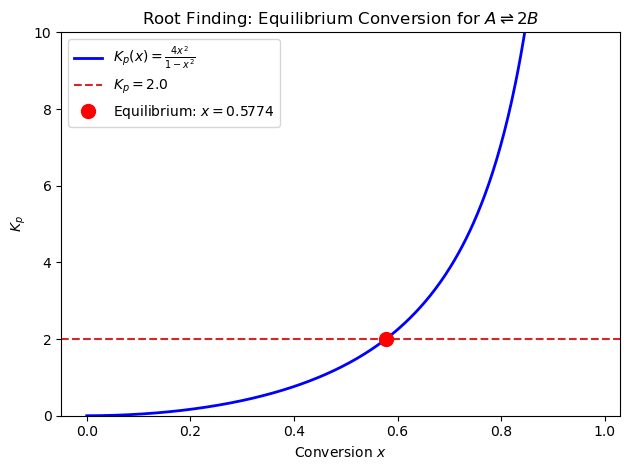

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Kp = 2.0

# Polynomial: (4 + Kp)*x^2 - Kp = 0
# coefficients in descending order: [4 + Kp, 0, -Kp]
coeffs = [4 + Kp, 0, -Kp]
p = np.poly1d(coeffs)

print("Equilibrium polynomial p(x) =")
print(p)

# Find all roots
roots = p.roots
print(f"\nAll roots: {roots.round(6)}")

# Keep only the physically meaningful root: real, 0 < x < 1
real_roots = roots[np.isreal(roots)].real
x_eq = real_roots[(real_roots > 0) & (real_roots < 1)] # Boolean indexing: This keeps only the elements where the condition is True.
print(f"Physical root (0 < x < 1): x = {x_eq[0]:.6f}")

# Verify: Kp = 4x² / (1 - x²)
x_sol = x_eq[0]
Kp_check = 4 * x_sol**2 / (1 - x_sol**2)
print(f"\nVerification: Kp = 4x²/(1-x²) = {Kp_check:.6f}  (expected {Kp})")

# Plot Kp(x) = 4x² / (1 - x²) and mark the solution
x = np.linspace(0, 0.98, 400)
Kp_curve = 4 * x**2 / (1 - x**2)


plt.plot(x, Kp_curve, 'b-', linewidth=2, label=r'$K_p(x) = \frac{4x^2}{1-x^2}$')
plt.axhline(Kp, color='tab:red', linestyle='--', linewidth=1.5, label=f'$K_p = {Kp}$')
plt.plot(x_sol, Kp, 'ro', markersize=10, zorder=5,
        label=f'Equilibrium: $x = {x_sol:.4f}$')
plt.xlabel('Conversion $x$')
plt.ylabel('$K_p$')
plt.title(r'Root Finding: Equilibrium Conversion for $A \rightleftharpoons 2B$')
plt.ylim(0, 10)
plt.legend()
plt.tight_layout()
plt.show()

In [3]:
real_roots = roots[np.isreal(roots)].real

real_roots[(real_roots > 0) & (real_roots < 1)]

array([0.57735027])

### Example 3: Fitting $C_p(T)$ for CO$_2$ with `np.polyfit`

Below is NIST tabulated heat capacity data for CO$_2$. Use `np.polyfit` to fit degree 2 polynomial, then:
1. Plot fit against the data
2. Compute and print MAE, MSE, and $R^2$ for each degree

$$
\text{MAE} = \frac{1}{N}\sum|e_i|, \quad
\text{MSE} = \frac{1}{N}\sum e_i^2, \quad
R^2 = 1 - \frac{\sum e_i^2}{\sum(y_i - \bar{y})^2}
$$

| $T$ (K) | 300 | 400 | 500 | 600 | 700 | 800 | 900 | 1000 | 1100 | 1200 |
|---------|-----|-----|-----|-----|-----|-----|-----|------|------|------|
| $C_p$ (J/mol/K) | 37.13 | 41.33 | 44.60 | 47.33 | 49.65 | 51.61 | 53.26 | 54.31 | 55.37 | 56.21 |

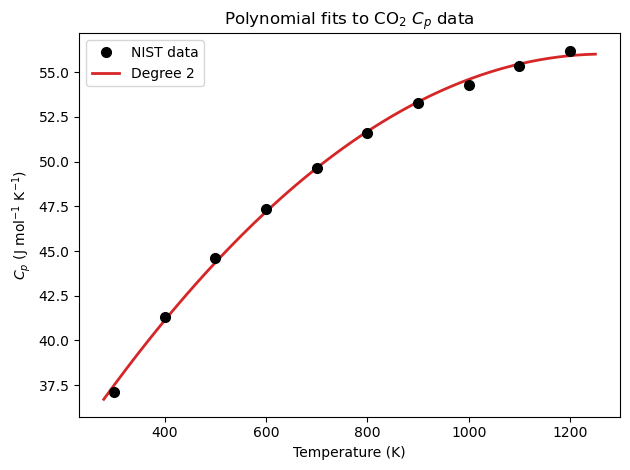

Degree     MAE (J/mol/K)    MSE (J/mol/K)²        R²
-------------------------------------------------------
     2          0.179212          0.043519  0.998817
     2          0.179212          0.043519  0.998817


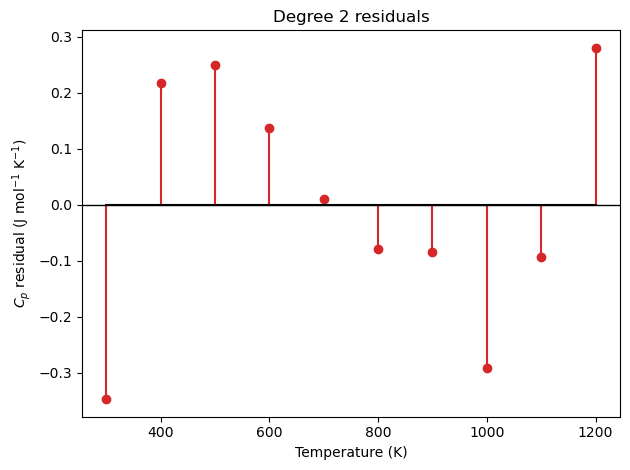

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# NIST tabulated Cp data for CO2
T_data  = np.array([300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200], dtype=float)
Cp_data = np.array([37.13, 41.33, 44.60, 47.33, 49.65,
                    51.61, 53.26, 54.31, 55.37, 56.21])

T_fine  = np.linspace(280, 1250, 300)
degree = 2
colors  = ['tab:red', 'tab:orange', 'tab:blue']
fits    = np.polyfit(T_data, Cp_data, degree)


# ── Plot fits ─────────────────────────────────────────────────────────────────
#fig, ax = plt.subplots(figsize=(9, 4))

plt.plot(T_data, Cp_data, 'ko', markersize=7, zorder=5, label='NIST data')
plt.plot(T_fine, np.polyval(fits, T_fine), color='tab:red', linewidth=2, label=f'Degree {degree}')
plt.xlabel('Temperature (K)')
plt.ylabel(r'$C_p$ (J mol$^{-1}$ K$^{-1}$)')
plt.title(r'Polynomial fits to CO$_2$ $C_p$ data')
plt.legend()
plt.tight_layout()
plt.show()

# ── Metrics ───────────────────────────────────────────────────────────────────
SS_tot = np.sum((Cp_data - np.mean(Cp_data))**2)
print(f"{'Degree':>6}  {'MAE (J/mol/K)':>16}  {'MSE (J/mol/K)²':>16}  {'R²':>8}")
print("-" * 55)
Cp_pred = np.polyval(fits, T_data)
res = Cp_data - Cp_pred
MAE = np.mean(np.abs(res))
MSE = np.mean(res**2)
R2  = 1.0 - np.sum(res**2) / SS_tot
print(f"{degree:>6}  {MAE:>16.6f}  {MSE:>16.6f}  {R2:>8.6f}")

# Note: by using scikitt-learn
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# MAE = mean_absolute_error(Cp_data, Cp_pred)
# MSE = mean_squared_error(Cp_data, Cp_pred)
# R2  = r2_score(Cp_data, Cp_pred)
# print(f"{degree:>6}  {MAE:>16.6f}  {MSE:>16.6f}  {R2:>8.6f}")


# ── Residual stem plots ───────────────────────────────────────────────────────

residuals = Cp_data - np.polyval(fits, T_data)
plt.stem(T_data, residuals, linefmt='tab:red', markerfmt='o', basefmt='k-')
plt.axhline(0, color='k', linewidth=1)
plt.xlabel('Temperature (K)')
plt.title(f'Degree {degree} residuals')
plt.ylabel(r'$C_p$ residual (J mol$^{-1}$ K$^{-1}$)')
plt.tight_layout()
plt.show()

---

## Warm-Up: Syntax Practice

Short exercises to get comfortable with the key NumPy polynomial functions before the main problems.

**Exercise 1 — Define a polynomial.**

Define $q(x) = x^2 - 5x + 6$ using `np.poly1d` and print it. Then confirm that the coefficients stored inside match what you passed in.

In [ ]:
import numpy as np

# Define q(x) = x^2 - 5x + 6
q = np.poly1d([1, -5, 6])

print(q)
print("Coefficients:", q.coeffs)  # should print [1, -5, 6]

**Exercise 2 — Evaluate at a point.**

Using the same $q(x) = x^2 - 5x + 6$, evaluate $q(2)$ and $q(3)$ two ways: via the `poly1d` object and via `np.polyval`. Confirm both give the same answer, and check manually that the values make sense (hint: $q(2) = 0$ and $q(3) = 0$).

In [15]:
import numpy as np

coeffs = [1, -5, 6]
q = np.poly1d(coeffs)

for x_val in [2, 3]:
    via_poly1d = q(x_val)          # call q like a function
    via_polyval = np.polyval(coeffs, x_val)         # use np.polyval
    print(f"q({x_val}): poly1d = {via_poly1d},  polyval = {via_polyval}")

q(2): poly1d = 0,  polyval = 0
q(3): poly1d = 0,  polyval = 0


**Exercise 3 — Find roots.**

Find the roots of $q(x) = x^2 - 5x + 6$ using `p.roots`. You should get two real roots. Print them and verify they match what you'd get by factoring: $q(x) = (x-2)(x-3)$.

In [16]:
import numpy as np

q = np.poly1d([1, -5, 6])

roots = q.roots         # get the roots of q
print("Roots:", roots)

# Verify by evaluating q at each root — should both be ~0
for r in roots:
    print(f"q({r:.1f}) = {q(r):.6f}")

Roots: [3. 2.]
q(3.0) = 0.000000
q(2.0) = 0.000000


**Exercise 4 — Fit a polynomial to data.**

Five measurements of reaction rate $r$ at different temperatures $T$ are given below. Fit a degree-2 polynomial using `np.polyfit`, then evaluate it at $T = 350$ K.

| $T$ (K)       | 300  | 325  | 350  | 375  | 400  |
|:-------------:|:----:|:----:|:----:|:----:|:----:|
| $r$ (mol/L/s) | 1.2  | 2.3  | 3.8  | 5.7  | 8.1  |

In [17]:
import numpy as np

T_data = np.array([300, 325, 350, 375, 400], dtype=float)
r_data = np.array([1.2, 2.3, 3.8, 5.7, 8.1])

# Fit a degree-2 polynomial
coeffs = np.polyfit(T_data, r_data, 2)   # x, y, degree
p = np.poly1d(coeffs)

print("Fitted polynomial:")
print(p)

# Evaluate at T = 350 K
T_query = 350.0
print(f"\nr({T_query} K) = {p(T_query):.4f} mol/L/s")   # call p at T_query

Fitted polynomial:
           2
0.0003429 x - 0.1712 x + 21.71

r(350.0 K) = 3.7914 mol/L/s


---

## Practice Problems (by students)

### Problem 1: Polynomial Evaluation

Consider the polynomial $p(x) = 4x^3 - 2x^2 + 7x - 1$.

1. Create it as a `np.poly1d` object and print its representation.
2. Evaluate $p(3)$ using both `poly1d` and `np.polyval`. Verify manually.
3. Find all roots of $p(x)$. Which roots are real? Which are complex?
4. Plot $p(x)$ over $x \in [-2, 4]$ and mark the real root(s) with a red dot.

**Hint:** `p.roots` returns all roots (may be complex); filter with `np.isreal()` to find real ones.

p(x) =
   3     2
4 x - 2 x + 7 x - 1

p(3) via poly1d  : 110.0000
p(3) via polyval : 110.0000
Manual check        : 110.0000

All roots: [0.1764+1.2911j 0.1764-1.2911j 0.1472+0.j    ]
Real roots: [0.1472]


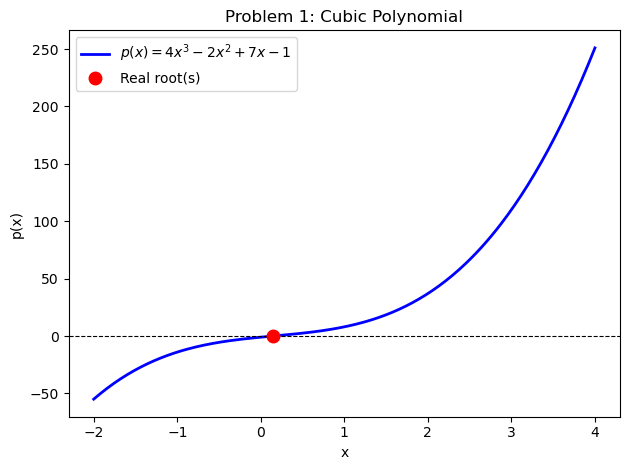

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create poly1d object
coeffs = [4, -2, 7, -1]
p = np.poly1d(coeffs)
print("p(x) =")
print(p)

# 2. Evaluate at x = 3
x_val = 3
print(f"\np({x_val}) via poly1d  : {p(x_val):.4f}")
print(f"p({x_val}) via polyval : {np.polyval(coeffs, x_val):.4f}")
print(f"Manual check        : {4*x_val**3 - 2*x_val**2 + 7*x_val - 1:.4f}")

# 3. All roots (may be complex)
roots = p.roots
print(f"\nAll roots: {roots.round(4)}")
real_roots = roots[np.isreal(roots)].real
print(f"Real roots: {real_roots.round(4)}")

# 4. Plot
x = np.linspace(-2, 4, 300)
y = np.polyval(coeffs, x)


plt.plot(x, y, 'b-', linewidth=2, label=r'$p(x) = 4x^3 - 2x^2 + 7x - 1$')
plt.axhline(0, color='k', linewidth=0.8, linestyle='--')
if len(real_roots) > 0:
    plt.plot(real_roots, np.polyval(coeffs, real_roots), 'ro',
             markersize=9, zorder=5, label=f'Real root(s)')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.title('Problem 1: Cubic Polynomial')
plt.legend()
plt.tight_layout()
plt.show()

### Problem 2: Fitting Viscosity Data — Degrees of Freedom & Overfitting

The dynamic viscosity of liquid water varies with temperature (11 data points):

| $T$ (°C) | 0 | 10 | 20 | 30 | 40 | 50 | 60 | 70 | 80 | 90 | 100 |
|----------|---|----|----|----|----|----|----|----|----|-----|-----|
| $\mu$ (mPa·s) | 1.793 | 1.307 | 1.002 | 0.798 | 0.653 | 0.547 | 0.467 | 0.404 | 0.355 | 0.315 | 0.282 |

**(a)** Fill in the degrees of freedom table below. Recall: $\text{DOF} = N - (n+1)$ where $N$ = number of data points and $n$ = polynomial degree.

| Degree $n$ | Parameters $n+1$ | DOF = $11 - (n+1)$ | Overdetermined? |
|:----------:|:----------------:|:-------------------:|:---------------:|
| 1          |                  |                     |                 |
| 3          |                  |                     |                 |
| 5          |                  |                     |                 |
| 10         |                  |                     |                 |

**(b)** Fit polynomials of degree 1, 3, 5, and 10, plot all fits over $T \in [-10, 120]$ °C, and print MAE and $R^2$ for each. Then answer: which degrees overfit, and how can you tell?

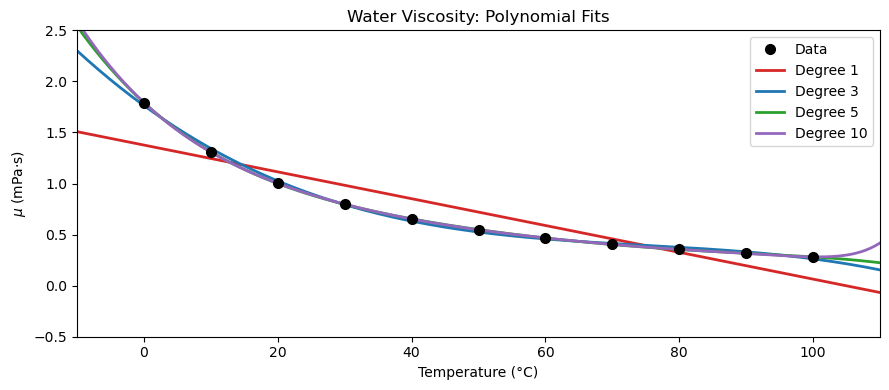

Degree    DOF     MAE (mPa·s)          R²
---------------------------------------------
     1      9        0.153527    0.835236
     3      7        0.019299    0.997815
     5      5        0.001522    0.999986
    10      0        0.000000    1.000000


In [4]:
import numpy as np
import matplotlib.pyplot as plt

T_data  = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100], dtype=float)
mu_data = np.array([1.793, 1.307, 1.002, 0.798, 0.653, 0.547,
                    0.467, 0.404, 0.355, 0.315, 0.282])

degrees = [1, 3, 5, 10]
colors  = ['tab:red', 'tab:blue', 'tab:green', 'tab:purple']
T_fine  = np.linspace(-10, 120, 400)

# (b-1) Fit each degree — complete the polyfit call
fits = {}
for deg in degrees:
    fits[deg] = np.polyfit(T_data, mu_data, deg)   # x, y, degree

# (b-2) Plot
plt.figure(figsize=(9, 4))
plt.plot(T_data, mu_data, 'ko', markersize=7, zorder=5, label='Data')
for deg, color in zip(degrees, colors):
    plt.plot(T_fine, np.polyval(fits[deg], T_fine),
             color=color, linewidth=2, label=f'Degree {deg}')
plt.xlim(-10, 110)
plt.ylim(-0.5, 2.5)
plt.xlabel('Temperature (°C)')
plt.ylabel(r'$\mu$ (mPa·s)')
plt.title('Water Viscosity: Polynomial Fits')
plt.legend()
plt.tight_layout()
plt.show()

# (b-3) Metrics
N      = len(T_data)
SS_tot = np.sum((mu_data - np.mean(mu_data))**2)
print(f"{'Degree':>6}  {'DOF':>5}  {'MAE (mPa·s)':>14}  {'R²':>10}")
print("-" * 45)
for deg in degrees:
    res = mu_data - np.polyval(fits[deg], T_data)
    MAE = np.mean(np.abs(res))           # mean absolute error
    R2  = 1.0 - np.sum(res**2) / SS_tot # R-squared
    dof = N - (deg + 1)                  # degrees of freedom
    print(f"{deg:>6}  {dof:>5}  {MAE:>14.6f}  {R2:>10.6f}")

**(a) DOF table — fill in your answers:**

| Degree $n$ | Parameters $n+1$ | DOF | Overdetermined? |
|:----------:|:----------------:|:---:|:---------------:|
| 1          | 2                | 9   | Yes             |
| 3          | 4                | 7   | Yes             |
| 5          | 6                | 5   | Yes             |
| 10         | 11               | 0   | No (exact fit)  |

**(b) Which degrees overfit, and how can you tell?**

*Your answer here:*